# Поиск частых наборов объектов (алгоритм Apriori)

Задание: реализовать алгоритм Apriori для поиска частых наборов объектов в наборе
данных о покупках в супермаркете (`baskets.csv`). Программа принимает три параметра:

1. набор данных (список транзакций);
2. порог поддержки (support threshold);
3. способ упорядочивания результата: по убыванию поддержки или лексикографически.

Результат: список пар (набор объектов, значение поддержки).

Далее проводятся эксперименты с порогами 1%, 3%, 5%, 10%, 15% и визуализация:

- быстродействие алгоритма в зависимости от порога поддержки;
- количество найденных частых наборов разной длины в зависимости от порога.


In [1]:
import csv
import time
from collections import defaultdict, Counter
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = "baskets.csv"


## 1. Загрузка данных

Файл `baskets.csv` это список транзакций (чеков): каждая строка это набор товаров,
купленных за одно посещение магазина, без заголовка и без идентификатора чека.
Файл в кодировке `cp1251` (кириллица).

In [ ]:
def load_transactions(path, encoding="cp1251"):
    """Читает csv с транзакциями и возвращает список наборов товаров."""
    transactions = []
    with open(path, encoding=encoding) as f:
        reader = csv.reader(f)
        for row in reader:
            items = frozenset(x.strip() for x in row if x.strip())#Удаление пробелов н+к
            if items:
                transactions.append(items)
    return transactions


transactions = load_transactions(DATA_PATH)

all_items = set().union(*transactions)
lengths = [len(t) for t in transactions]

print(f"Число транзакций: {len(transactions)}")
print(f"Число уникальных товаров: {len(all_items)}")
print(f"Средняя длина транзакции: {sum(lengths) / len(lengths):.2f}")
print(f"Максимальная длина транзакции: {max(lengths)}")


Число транзакций: 7501
Число уникальных товаров: 115
Средняя длина транзакции: 3.91
Максимальная длина транзакции: 20


## 2. Алгоритм Apriori

Идея алгоритма:

1. Находим частые наборы из одного товара: считаем, сколько раз встречается
   каждый товар, и оставляем только те, что не реже порога поддержки.
2. Пока есть частые наборы предыдущего размера:
   - строим кандидатов следующего размера из товаров, встречавшихся в частых
     наборах, и отбрасываем кандидата, если хотя бы одно его подмножество не
     является частым (это и есть главная идея Apriori: подмножество частого
     набора тоже обязано быть частым);
   - считаем поддержку оставшихся кандидатов по всем транзакциям;
   - оставляем только тех, кто прошёл порог.
3. Собираем все найденные наборы вместе.

Код разбит на простые функции, каждая отвечает за один шаг.

In [3]:
def get_frequent_items(transactions, min_count):
    """Находит частые наборы из одного товара."""
    counts = defaultdict(int)
    for transaction in transactions:
        for item in transaction:
            counts[item] += 1

    return {frozenset([item]): count for item, count in counts.items()
            if count >= min_count}


def generate_candidates(frequent_itemsets, size):
    """Строит кандидатов заданного размера из уже найденных частых наборов."""
    items = set()
    for itemset in frequent_itemsets:
        items.update(itemset)

    candidates = set()
    for combo in combinations(sorted(items), size):
        candidate = frozenset(combo)
        subsets = combinations(candidate, size - 1)
        if all(frozenset(subset) in frequent_itemsets for subset in subsets):
            candidates.add(candidate)

    return candidates


def count_support(transactions, candidates):
    """Считает, сколько раз каждый кандидат встречается в транзакциях."""
    counts = defaultdict(int)
    for transaction in transactions:
        for candidate in candidates:
            if candidate <= transaction:
                counts[candidate] += 1
    return counts


def apriori(transactions, min_support, sort_by="support_desc"):
    """
    Поиск частых наборов объектов методом Apriori.

    transactions: список транзакций (наборов товаров)
    min_support: порог поддержки, доля от 0 до 1 (например, 0.05 = 5%)
    sort_by: "support_desc" (по убыванию поддержки) или "lexicographic"

    Возвращает список пар (набор объектов, значение поддержки).
    """
    n = len(transactions)
    min_count = min_support * n

    frequent_itemsets = get_frequent_items(transactions, min_count)
    all_frequent = dict(frequent_itemsets)

    size = 2
    while frequent_itemsets:
        candidates = generate_candidates(frequent_itemsets, size)
        if not candidates:
            break

        counts = count_support(transactions, candidates)
        frequent_itemsets = {itemset: count for itemset, count in counts.items()
                              if count >= min_count}

        all_frequent.update(frequent_itemsets)
        size += 1

    results = [(itemset, count / n) for itemset, count in all_frequent.items()]

    if sort_by == "support_desc":
        results.sort(key=lambda pair: (-pair[1], sorted(pair[0])))
    elif sort_by == "lexicographic":
        results.sort(key=lambda pair: sorted(pair[0]))
    else:
        raise ValueError("sort_by должен быть 'support_desc' или 'lexicographic'")

    return results


## 3. Пробный запуск

Проверим работу функции на пороге поддержки 10% в обоих режимах сортировки.

In [4]:
demo = apriori(transactions, min_support=0.10, sort_by="support_desc")
print(f"Найдено {len(demo)} частых наборов при пороге 10% (сортировка по поддержке):\n")
for itemset, support in demo:
    print(f"  {sorted(itemset)}  ->  support = {support:.4f}")


Найдено 7 частых наборов при пороге 10% (сортировка по поддержке):

  ['минеральная вода']  ->  support = 0.2384
  ['макароны']  ->  support = 0.1880
  ['яйца']  ->  support = 0.1797
  ['картофель-фри']  ->  support = 0.1709
  ['шоколад']  ->  support = 0.1638
  ['зеленый чай']  ->  support = 0.1321
  ['молоко']  ->  support = 0.1296


In [5]:
demo_lex = apriori(transactions, min_support=0.10, sort_by="lexicographic")
print("Те же наборы, лексикографическая сортировка:\n")
for itemset, support in demo_lex:
    print(f"  {sorted(itemset)}  ->  support = {support:.4f}")


Те же наборы, лексикографическая сортировка:

  ['зеленый чай']  ->  support = 0.1321
  ['картофель-фри']  ->  support = 0.1709
  ['макароны']  ->  support = 0.1880
  ['минеральная вода']  ->  support = 0.2384
  ['молоко']  ->  support = 0.1296
  ['шоколад']  ->  support = 0.1638
  ['яйца']  ->  support = 0.1797


## 4. Эксперименты

Прогоняем Apriori на `baskets.csv` при порогах поддержки 1%, 3%, 5%, 10%, 15%,
замеряя время выполнения и число найденных наборов в разбивке по длине.

In [6]:
thresholds = [0.01, 0.03, 0.05, 0.10, 0.15]

experiment_rows = []

for threshold in thresholds:
    start_time = time.perf_counter()
    result = apriori(transactions, min_support=threshold, sort_by="support_desc")
    elapsed = time.perf_counter() - start_time

    counts_by_length = Counter(len(itemset) for itemset, _ in result)

    row = {
        "threshold_%": threshold * 100,
        "total_itemsets": len(result),
        "time_sec": elapsed,
    }
    for length in range(1, 6):
        row[f"len_{length}"] = counts_by_length.get(length, 0)

    experiment_rows.append(row)

experiments_df = pd.DataFrame(experiment_rows)
experiments_df


,threshold_%,total_itemsets,time_sec,len_1,len_2,len_3,len_4,len_5
0,1.0,261,9.943917,74,170,17,0,0
1,3.0,55,1.098683,36,19,0,0,0
2,5.0,28,0.459966,25,3,0,0,0
3,10.0,7,0.047911,7,0,0,0,0
4,15.0,5,0.029599,5,0,0,0,0


## 5. Визуализация: быстродействие в зависимости от порога поддержки

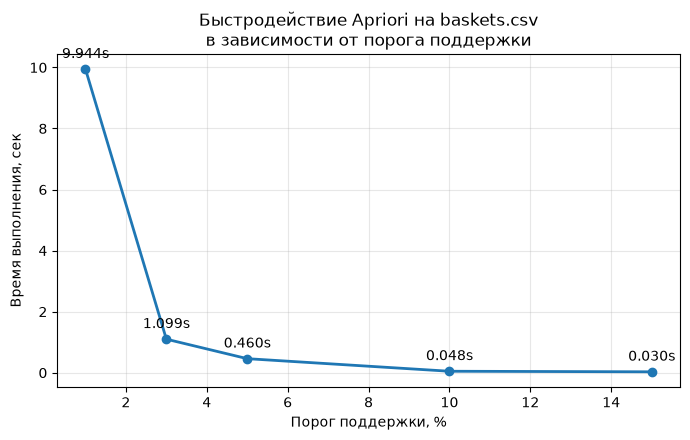

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(experiments_df["threshold_%"], experiments_df["time_sec"], marker="o", linewidth=2)
ax.set_xlabel("Порог поддержки, %")
ax.set_ylabel("Время выполнения, сек")
ax.set_title("Быстродействие Apriori на baskets.csv\nв зависимости от порога поддержки")
ax.grid(True, alpha=0.3)

for x, y in zip(experiments_df["threshold_%"], experiments_df["time_sec"]):
    ax.annotate(f"{y:.3f}s", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")

plt.tight_layout()
plt.savefig("runtime_vs_support.png", dpi=150)
plt.show()


## 6. Визуализация: количество частых наборов по длине

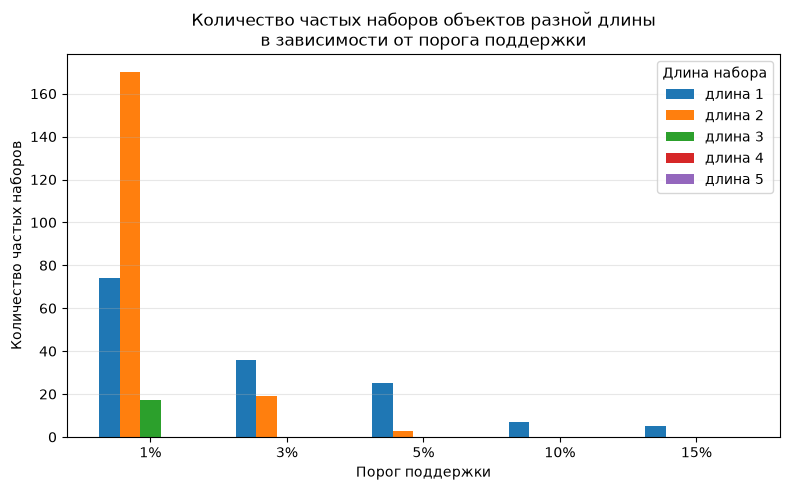

In [8]:
length_columns = [c for c in experiments_df.columns if c.startswith("len_")]

fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.15
positions = range(len(experiments_df))

for i, column in enumerate(length_columns):
    offsets = [p + i * bar_width for p in positions]
    length_label = column.split("_")[1]
    ax.bar(offsets, experiments_df[column], width=bar_width, label=f"длина {length_label}")

tick_positions = [p + bar_width * (len(length_columns) - 1) / 2 for p in positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels([f"{t:.0f}%" for t in experiments_df["threshold_%"]])
ax.set_xlabel("Порог поддержки")
ax.set_ylabel("Количество частых наборов")
ax.set_title("Количество частых наборов объектов разной длины\nв зависимости от порога поддержки")
ax.legend(title="Длина набора")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("itemset_counts_by_length.png", dpi=150)
plt.show()


## 7. Выводы

- С понижением порога поддержки число частых наборов растёт, причём резко: на
  низких порогах (1%) в результат попадают наборы большей длины (2 и 3 товара),
  которых нет при высоких порогах.
- Время выполнения Apriori растёт вместе с числом кандидатов на каждом уровне.
  При пороге 1% алгоритм работает заметно дольше, чем при 15%, потому что
  приходится строить и проверять намного больше кандидатов размера 2 и 3.
- При высоких порогах (10 15%) находятся только самые популярные отдельные
  товары (наборы длины 1). Совместные покупки товаров становятся заметны
  начиная примерно с порогов 3 5% и ниже.
- Такое поведение ожидаемо и показывает главный компромисс частотного анализа:
  более низкий порог даёт более детальную картину совместных покупок, но
  требует значительно больше вычислений.
